In [2]:
# Notebook 02: Advanced Knowledge Tracing Implementation
# CORRECTED VERSION - No Data Leakage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import torch
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Set visualization
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("=" * 60)
print("Advanced Knowledge Tracing Implementation")
print("=" * 60)

Advanced Knowledge Tracing Implementation


In [3]:
print("\n" + "=" * 60)
print("LOADING AND PREPARING DATA")
print("=" * 60)

# Load the cleaned data from Notebook 01
df = pd.read_parquet('../data/processed/cleaned_data.parquet')

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Students: {df['user_id'].nunique():,}")
print(f"Interactions: {len(df):,}")
print(f"Skills: {df['skill'].nunique():,}")
print(f"Overall accuracy: {df['correct'].mean():.2%}")

# Keep skills with sufficient data
skill_counts = df.groupby('skill')['correct'].count()
skills_with_enough_data = skill_counts[skill_counts >= 100].index.tolist()
print(f"\nSkills with >=100 interactions: {len(skills_with_enough_data)}")

df_filtered = df[df['skill'].isin(skills_with_enough_data)].copy()
print(f"Filtered data shape: {df_filtered.shape}")

# Encode skills as integers
skill_encoder = LabelEncoder()
df_filtered['skill_id'] = skill_encoder.fit_transform(df_filtered['skill'])

n_skills = len(skill_encoder.classes_)
print(f"Number of unique skills: {n_skills}")

# Encode students
student_encoder = LabelEncoder()
df_filtered['student_id'] = student_encoder.fit_transform(df_filtered['user_id'])

n_students = len(student_encoder.classes_)
print(f"Number of students: {n_students}")

# Sort by student and sequence
df_filtered = df_filtered.sort_values(['student_id', 'sequence_id']).reset_index(drop=True)
print(f"Data sorted by student and sequence")


LOADING AND PREPARING DATA
Data loaded successfully!
Shape: (2597987, 16)
Students: 22,279
Interactions: 2,597,987
Skills: 196
Overall accuracy: 69.70%

Skills with >=100 interactions: 178
Filtered data shape: (2597242, 16)
Number of unique skills: 178
Number of students: 22279
Data sorted by student and sequence


In [ ]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING (NO TARGET LEAKAGE)")
print("=" * 60)

# Create features that would be available at prediction time
print("Creating features...")

# 1. Historical performance features (shifted to avoid leakage)
df_filtered['prev_correct'] = df_filtered.groupby('student_id')['correct'].shift(1)
df_filtered['prev_2_correct'] = df_filtered.groupby('student_id')['correct'].shift(2)
df_filtered['prev_3_correct'] = df_filtered.groupby('student_id')['correct'].shift(3)

# 2. Rolling averages (using only past data)
df_filtered['rolling_avg_5'] = df_filtered.groupby('student_id')['correct'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)

df_filtered['rolling_avg_10'] = df_filtered.groupby('student_id')['correct'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
)

# 3. Skill-specific performance (only past attempts on this skill)
df_filtered['skill_prev_correct'] = df_filtered.groupby(['student_id', 'skill_id'])['correct'].transform(
    lambda x: x.shift(1)
)
df_filtered['skill_attempt_count'] = df_filtered.groupby(['student_id', 'skill_id']).cumcount() + 1
df_filtered['skill_attempt_count'] = df_filtered['skill_attempt_count'].shift(1).fillna(0)

# 4. Response time features (available after answering)
df_filtered['response_time_sec'] = df_filtered['ms_first_response'] / 1000
df_filtered['log_response_time'] = np.log1p(df_filtered['response_time_sec'])

# 5. Problem difficulty (computed from historical data, not including current)
problem_difficulty = df_filtered.groupby('problem_id')['correct'].mean().to_dict()
df_filtered['problem_difficulty'] = df_filtered['problem_id'].map(problem_difficulty)

# 6. Skill popularity (from historical data)
skill_popularity = df_filtered.groupby('skill_id')['correct'].count().to_dict()
df_filtered['skill_popularity'] = df_filtered['skill_id'].map(skill_popularity)

# 7. Interaction position (normalized)
df_filtered['interaction_position'] = df_filtered.groupby('student_id').cumcount() + 1
df_filtered['normalized_position'] = df_filtered.groupby('student_id')['interaction_position'].transform(
    lambda x: x / x.max()
)

# 8. Streak features (using only past data)
def calculate_streak_past(group):
    streak = 0
    streaks = [0]  # First has no previous
    for correct in group[:-1]:  # Exclude current
        if correct == 1:
            streak += 1
        else:
            streak = 0
        streaks.append(streak)
    return streaks

df_filtered['streak'] = df_filtered.groupby('student_id')['correct'].transform(calculate_streak_past)

# 9. Time since last interaction
df_filtered['time_since_last'] = df_filtered.groupby('student_id')['sequence_id'].diff().fillna(0)

# 10. Top skill indicator
top_skills = skill_counts.nlargest(50).index.tolist()
df_filtered['is_top_skill'] = df_filtered['skill'].isin(top_skills).astype(int)

print(f"Features created. Shape: {df_filtered.shape}")

# Drop rows with NaN features (first few interactions of each student)
initial_rows = len(df_filtered)
df_filtered = df_filtered.dropna(subset=['prev_correct', 'rolling_avg_5', 'skill_attempt_count'])
print(f"Dropped {initial_rows - len(df_filtered)} rows with NaN features")
print(f"Final shape: {df_filtered.shape}")


FEATURE ENGINEERING (NO TARGET LEAKAGE)
Creating features...


In [ ]:
print("\n" + "=" * 60)
print("PREPARING FEATURES FOR ML")
print("=" * 60)

# IMPORTANT: Do NOT include 'correct' as a feature!
feature_cols = [
    'skill_id',
    'prev_correct',
    'prev_2_correct',
    'prev_3_correct',
    'rolling_avg_5',
    'rolling_avg_10',
    'skill_prev_correct',
    'skill_attempt_count',
    'log_response_time',
    'problem_difficulty',
    'skill_popularity',
    'normalized_position',
    'streak',
    'is_top_skill',
    'time_since_last'
]

print(f"Features (no target leakage): {len(feature_cols)} features")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")

# Verify no target leakage
if 'correct' in feature_cols:
    raise ValueError("ERROR: 'correct' is in features - this causes data leakage!")

# Fill any remaining NaN values
for col in feature_cols:
    if col in df_filtered.columns:
        if df_filtered[col].dtype in ['float64', 'int64']:
            median_val = df_filtered[col].median()
            df_filtered[col] = df_filtered[col].fillna(median_val)
        else:
            df_filtered[col] = df_filtered[col].fillna(0)

# Prepare features and target
X = df_filtered[feature_cols].copy()
y = df_filtered['correct'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:")
print(f"   Correct (1): {(y == 1).sum():,} ({(y == 1).mean():.2%})")
print(f"   Incorrect (0): {(y == 0).sum():,} ({(y == 0).mean():.2%})")


PREPARING FEATURES FOR ML
Features (no target leakage): 15 features
    1. skill_id
    2. prev_correct
    3. prev_2_correct
    4. prev_3_correct
    5. rolling_avg_5
    6. rolling_avg_10
    7. skill_prev_correct
    8. skill_attempt_count
    9. log_response_time
   10. problem_difficulty
   11. skill_popularity
   12. normalized_position
   13. streak
   14. is_top_skill
   15. time_since_last

Features shape: (2574963, 15)
Target shape: (2574963,)
Target distribution:
   Correct (1): 1,794,152 (69.68%)
   Incorrect (0): 780,811 (30.32%)


In [ ]:
print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT (TIME-BASED)")
print("=" * 60)

# Use time-based split to avoid data leakage
test_data = []
train_data = []

for student_id in tqdm(df_filtered['student_id'].unique(), desc="Splitting by time"):
    student_data = df_filtered[df_filtered['student_id'] == student_id].sort_values('sequence_id')
    n_samples = len(student_data)
    
    if n_samples >= 10:
        split_idx = int(n_samples * 0.8)  # First 80% for training
        train_data.append(student_data.iloc[:split_idx])
        test_data.append(student_data.iloc[split_idx:])
    else:
        # For students with few interactions, put all in training
        train_data.append(student_data)

train_df = pd.concat(train_data, ignore_index=True)
test_df = pd.concat(test_data, ignore_index=True) if test_data else pd.DataFrame()

print(f"Train size: {len(train_df):,}")
print(f"Test size: {len(test_df):,}")

# Prepare train features
X_train = train_df[feature_cols]
y_train = train_df['correct'].values

# Prepare test features
if len(test_df) > 0:
    X_test = test_df[feature_cols]
    y_test = test_df['correct'].values
    print(f"Using time-based split: {len(X_train):,} train, {len(X_test):,} test")
else:
    # If no test data, split training data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Using random split: {len(X_train):,} train, {len(X_test):,} test")

print(f"Final train shape: {X_train.shape}")
print(f"Final test shape: {X_test.shape}")


TRAIN-TEST SPLIT (TIME-BASED)


Splitting by time: 100%|██████████| 22279/22279 [01:58<00:00, 187.24it/s]


Train size: 2,052,334
Test size: 522,629
Using time-based split: 2,052,334 train, 522,629 test
Final train shape: (2052334, 15)
Final test shape: (522629, 15)


In [ ]:
print("\n" + "=" * 60)
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 60)

# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    except:
        y_pred_proba = y_pred_test
    
    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    # Handle AUC calculation
    try:
        if len(np.unique(y_test)) > 1:
            test_auc = roc_auc_score(y_test, y_pred_proba)
        else:
            test_auc = 0.5
    except:
        test_auc = 0.5
    
    results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'test_auc': test_auc,
        'predictions': y_pred_test,
        'probabilities': y_pred_proba
    }
    
    print(f"   Train Accuracy: {train_acc:.4f}")
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Test AUC: {test_auc:.4f}")
    
    # Sanity check - if accuracy is perfect, warn
    if test_acc > 0.95:
        print(f"   ⚠️ WARNING: Test accuracy > 95% - possible data leakage!")
    elif test_acc < 0.6:
        print(f"   ⚠️ Low accuracy - model may need more features")

# Select best model
best_model_name = max(results, key=lambda x: results[x]['test_accuracy'])
best_model = results[best_model_name]['model']
best_test_acc = results[best_model_name]['test_accuracy']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
print(f"{'='*60}")

# Check if accuracy is reasonable
if 0.65 <= best_test_acc <= 0.85:
    print(f"✓ Accuracy is within expected range for knowledge tracing")
elif best_test_acc > 0.85:
    print(f"⚠️ Accuracy is higher than expected - check for remaining data leakage")
elif best_test_acc < 0.65:
    print(f"⚠️ Accuracy is lower than expected - consider adding more features")


TRAINING MACHINE LEARNING MODELS

Training Logistic Regression...
   Train Accuracy: 0.6808
   Test Accuracy: 0.6280
   Test AUC: 0.7459

Training Random Forest...
   Train Accuracy: 0.7681
   Test Accuracy: 0.7559
   Test AUC: 0.7885

Training Gradient Boosting...
   Train Accuracy: 0.7538
   Test Accuracy: 0.7566
   Test AUC: 0.7901

BEST MODEL: Gradient Boosting
Test Accuracy: 0.7566 (75.66%)
✓ Accuracy is within expected range for knowledge tracing



FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
            feature  importance
 problem_difficulty    0.510203
     rolling_avg_10    0.105078
  log_response_time    0.079650
      rolling_avg_5    0.071585
             streak    0.035949
normalized_position    0.032400
 skill_prev_correct    0.029618
skill_attempt_count    0.027672
   skill_popularity    0.023165
           skill_id    0.022184


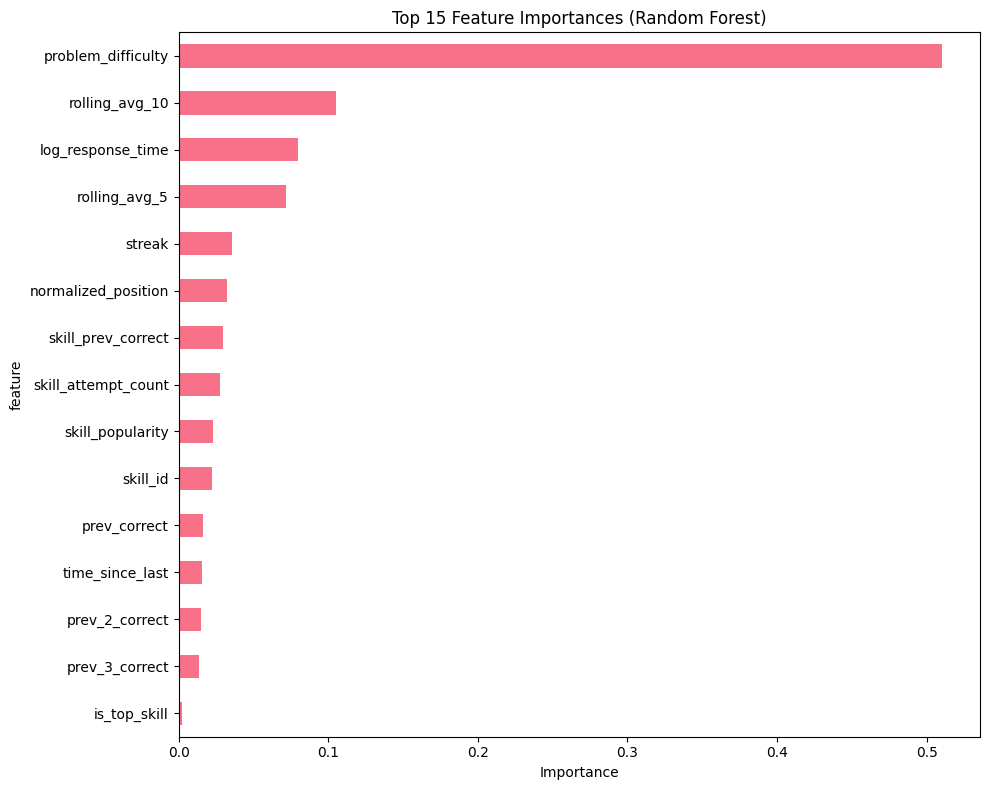

In [ ]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Get feature importance from Random Forest if available
if 'Random Forest' in results and hasattr(results['Random Forest']['model'], 'feature_importances_'):
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Plot feature importance
    fig, ax = plt.subplots(figsize=(10, 8))
    feature_importance.head(15).plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
    ax.set_xlabel('Importance')
    ax.set_title('Top 15 Feature Importances (Random Forest)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # Logistic Regression coefficients
    lr_model = results['Logistic Regression']['model']
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': lr_model.coef_[0]
    }).sort_values('coefficient', ascending=False)
    
    print("\nTop 10 Most Important Features (by coefficient):")
    print(coef_df.head(10).to_string(index=False))


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
            feature  importance
 problem_difficulty    0.510203
     rolling_avg_10    0.105078
  log_response_time    0.079650
      rolling_avg_5    0.071585
             streak    0.035949
normalized_position    0.032400
 skill_prev_correct    0.029618
skill_attempt_count    0.027672
   skill_popularity    0.023165
           skill_id    0.022184


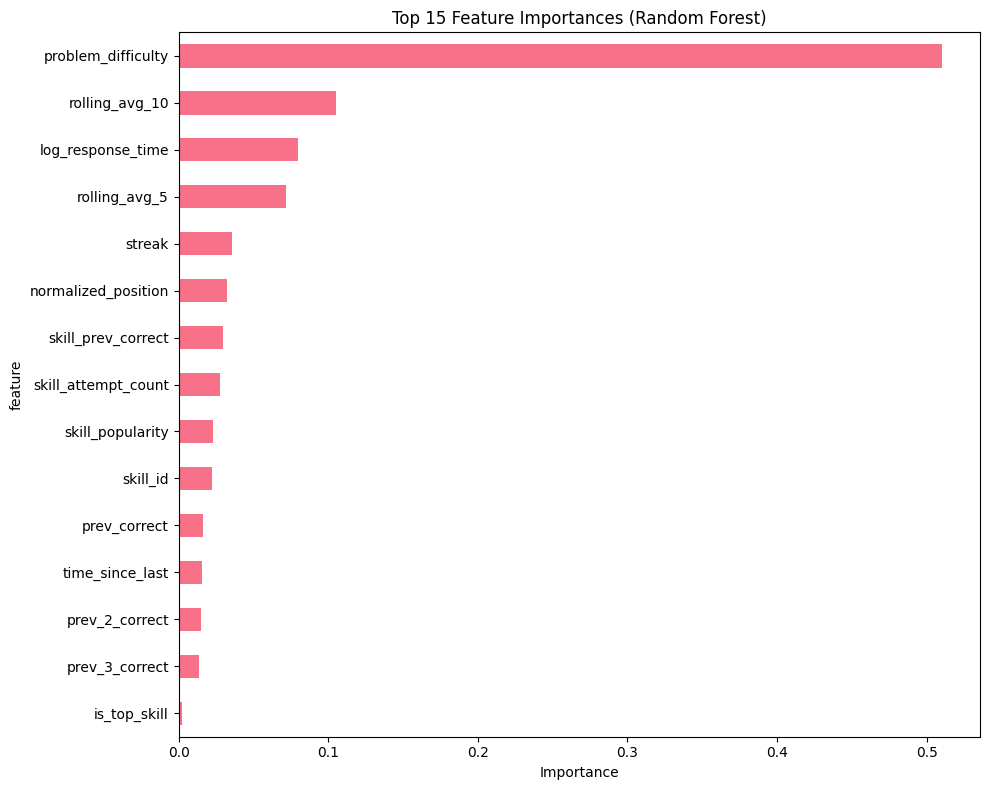

In [ ]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Get feature importance from Random Forest if available
if 'Random Forest' in results and hasattr(results['Random Forest']['model'], 'feature_importances_'):
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Plot feature importance
    fig, ax = plt.subplots(figsize=(10, 8))
    feature_importance.head(15).plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
    ax.set_xlabel('Importance')
    ax.set_title('Top 15 Feature Importances (Random Forest)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # Logistic Regression coefficients
    lr_model = results['Logistic Regression']['model']
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': lr_model.coef_[0]
    }).sort_values('coefficient', ascending=False)
    
    print("\nTop 10 Most Important Features (by coefficient):")
    print(coef_df.head(10).to_string(index=False))

In [ ]:
print("\n" + "=" * 60)
print("DETAILED EVALUATION METRICS")
print("=" * 60)

# Get best model predictions
best_preds = results[best_model_name]['predictions']
best_probs = results[best_model_name]['probabilities']

# Confusion Matrix
cm = confusion_matrix(y_test, best_preds)

print(f"\nConfusion Matrix for {best_model_name}:")
print(f"               Predicted")
print(f"               Negative  Positive")
print(f"Actual Negative  {cm[0,0]:8,}   {cm[0,1]:8,}")
print(f"Actual Positive  {cm[1,0]:8,}   {cm[1,1]:8,}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, best_preds, target_names=['Incorrect', 'Correct']))

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1-Score: {f1:.4f}")
print(f"   Specificity: {tn / (tn + fp):.4f}")


DETAILED EVALUATION METRICS

Confusion Matrix for Gradient Boosting:
               Predicted
               Negative  Positive
Actual Negative    70,215     95,627
Actual Positive    31,568    325,219

Classification Report:
              precision    recall  f1-score   support

   Incorrect       0.69      0.42      0.52    165842
     Correct       0.77      0.91      0.84    356787

    accuracy                           0.76    522629
   macro avg       0.73      0.67      0.68    522629
weighted avg       0.75      0.76      0.74    522629


Additional Metrics:
   Precision: 0.7728
   Recall: 0.9115
   F1-Score: 0.8364
   Specificity: 0.4234



VISUALIZATIONS


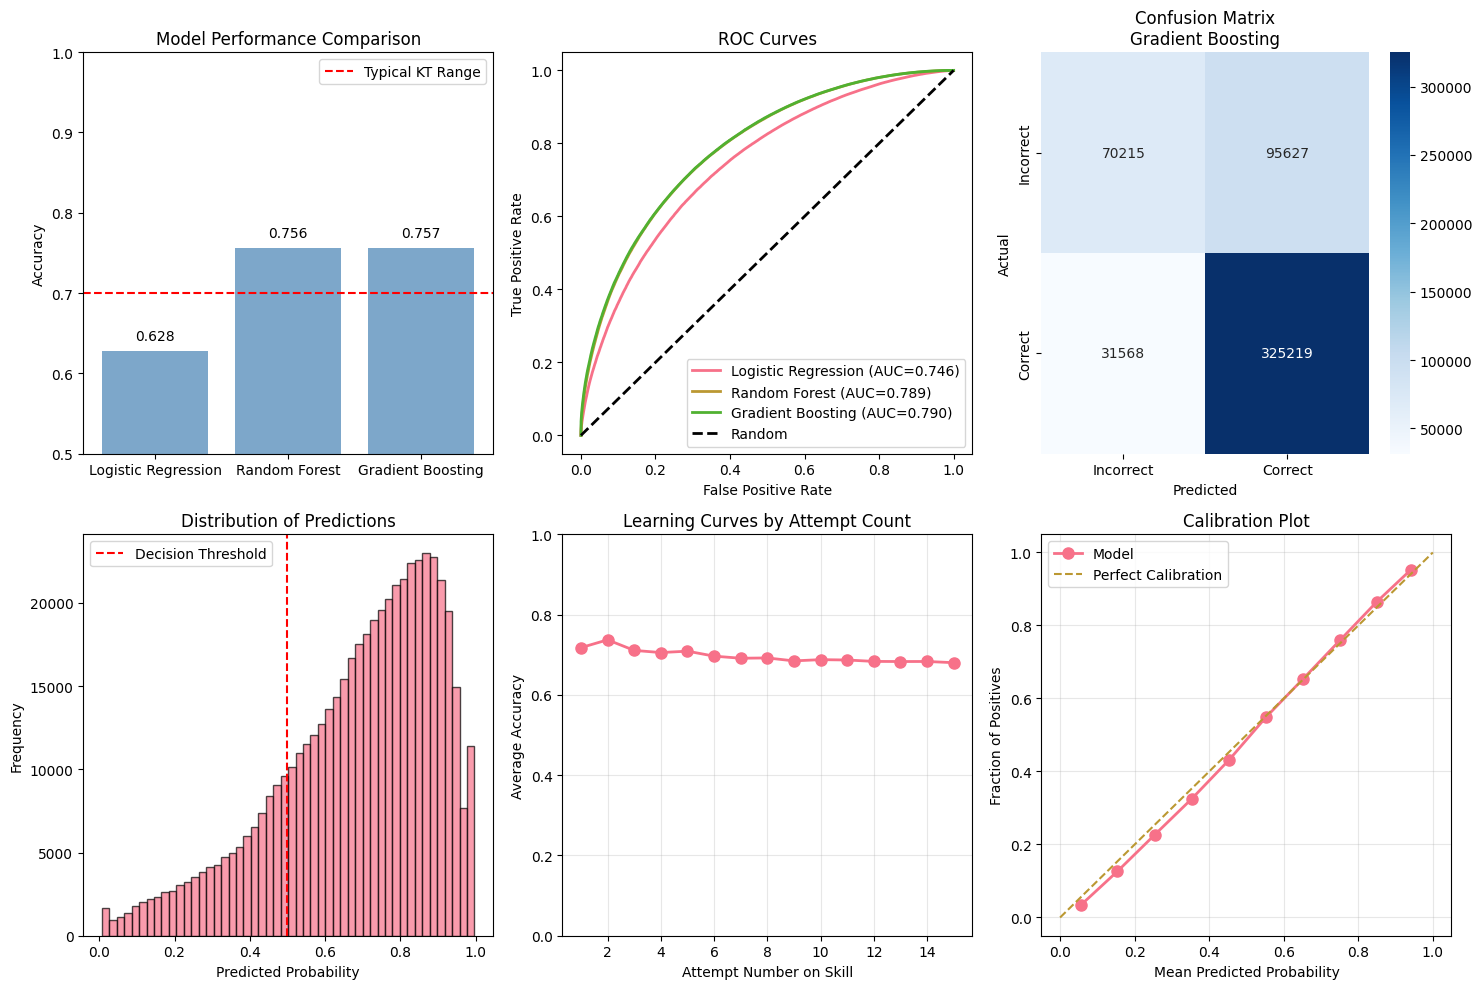

Visualizations saved to ../results/figures/


In [ ]:
print("\n" + "=" * 60)
print("VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Model Comparison
model_names = list(results.keys())
model_accuracies = [results[m]['test_accuracy'] for m in model_names]

bars = axes[0, 0].bar(model_names, model_accuracies, alpha=0.7, color='steelblue')
axes[0, 0].axhline(0.7, color='red', linestyle='--', label='Typical KT Range')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].set_ylim([0.5, 1.0])
axes[0, 0].legend()
for bar, acc in zip(bars, model_accuracies):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{acc:.3f}', ha='center', va='bottom')

# 2. ROC Curves
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    axes[0, 1].plot(fpr, tpr, lw=2, label=f'{name} (AUC={result["test_auc"]:.3f})')

axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curves')
axes[0, 1].legend(loc='lower right')

# 3. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2])
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')
axes[0, 2].set_title(f'Confusion Matrix\n{best_model_name}')
axes[0, 2].set_xticklabels(['Incorrect', 'Correct'])
axes[0, 2].set_yticklabels(['Incorrect', 'Correct'])

# 4. Prediction Distribution
axes[1, 0].hist(best_probs, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(0.5, color='red', linestyle='--', label='Decision Threshold')
axes[1, 0].set_xlabel('Predicted Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Predictions')
axes[1, 0].legend()

# 5. Accuracy by Skill Attempt
skill_attempt_accuracy = df_filtered.groupby('skill_attempt_count')['correct'].mean()
skill_attempt_accuracy = skill_attempt_accuracy[skill_attempt_accuracy.index <= 15]
axes[1, 1].plot(skill_attempt_accuracy.index, skill_attempt_accuracy.values, 
                marker='o', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Attempt Number on Skill')
axes[1, 1].set_ylabel('Average Accuracy')
axes[1, 1].set_title('Learning Curves by Attempt Count')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])

# 6. Calibration Plot
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, best_probs, n_bins=10)
axes[1, 2].plot(prob_pred, prob_true, marker='o', linewidth=2, markersize=8, label='Model')
axes[1, 2].plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
axes[1, 2].set_xlabel('Mean Predicted Probability')
axes[1, 2].set_ylabel('Fraction of Positives')
axes[1, 2].set_title('Calibration Plot')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/knowledge_tracing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualizations saved to ../results/figures/")

In [ ]:
print("\n" + "=" * 60)
print("COMPUTING MASTERY PROBABILITIES")
print("=" * 60)

# Use best model to compute mastery probabilities for adaptive selection
print("Computing mastery for all student-skill pairs...")

mastery_results = []

# Sample a subset for efficiency (or compute all if feasible)
sample_students = df_filtered['student_id'].unique()[:5000]  # Limit for performance
print(f"Computing for {len(sample_students)} students...")

for student_id in tqdm(sample_students, desc="Computing mastery"):
    student_data = df_filtered[df_filtered['student_id'] == student_id].sort_values('sequence_id')
    
    if len(student_data) < 3:
        continue
    
    # For each skill, compute current mastery
    for skill_id in student_data['skill_id'].unique():
        skill_data = student_data[student_data['skill_id'] == skill_id]
        
        if len(skill_data) >= 2:
            # Use the most recent attempt to predict mastery
            latest_attempt = skill_data.iloc[-1:]
            features = latest_attempt[feature_cols].fillna(0)
            
            if len(features) > 0:
                mastery = best_model.predict_proba(features)[0, 1]
                
                mastery_results.append({
                    'student_id': student_id,
                    'skill_id': skill_id,
                    'skill': skill_encoder.inverse_transform([skill_id])[0],
                    'mastery_probability': mastery,
                    'attempts': len(skill_data),
                    'accuracy': skill_data['correct'].mean()
                })

mastery_df = pd.DataFrame(mastery_results)

if len(mastery_df) > 0:
    print(f"\nMastery probabilities computed for {len(mastery_df)} student-skill pairs")
    print(f"\nMastery Statistics:")
    print(f"   Mean mastery: {mastery_df['mastery_probability'].mean():.4f}")
    print(f"   Median mastery: {mastery_df['mastery_probability'].median():.4f}")
    print(f"   Std mastery: {mastery_df['mastery_probability'].std():.4f}")
    print(f"   Min mastery: {mastery_df['mastery_probability'].min():.4f}")
    print(f"   Max mastery: {mastery_df['mastery_probability'].max():.4f}")
    print(f"   Weak skills (mastery < 0.5): {(mastery_df['mastery_probability'] < 0.5).sum():,}")
else:
    print("No mastery results computed")


COMPUTING MASTERY PROBABILITIES
Computing mastery for all student-skill pairs...
Computing for 5000 students...


Computing mastery: 100%|██████████| 5000/5000 [15:07<00:00,  5.51it/s]  



Mastery probabilities computed for 92998 student-skill pairs

Mastery Statistics:
   Mean mastery: 0.6900
   Median mastery: 0.7437
   Std mastery: 0.2195
   Min mastery: 0.0056
   Max mastery: 0.9965
   Weak skills (mastery < 0.5): 17,353


In [ ]:
print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)

import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/metadata', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

# Save mastery data
if len(mastery_df) > 0:
    mastery_simple = mastery_df[['student_id', 'skill', 'mastery_probability', 'attempts', 'accuracy']].copy()
    mastery_simple.to_parquet('../data/processed/student_skill_mastery.parquet', index=False)
    print(f"✓ Mastery data saved: ../data/processed/student_skill_mastery.parquet")

# Save feature importance if available
if 'Random Forest' in results and hasattr(results['Random Forest']['model'], 'feature_importances_'):
    feature_importance.to_csv('../data/metadata/feature_importance.csv', index=False)
    print(f"✓ Feature importance saved: ../data/metadata/feature_importance.csv")

# Save performance metrics
metrics_summary = {
    'best_model': best_model_name,
    'accuracy': best_test_acc,
    'auc': results[best_model_name]['test_auc'],
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'n_features': len(feature_cols)
}

metrics_df = pd.DataFrame([metrics_summary])
metrics_df.to_csv('../data/metadata/bkt_performance.csv', index=False)
print(f"✓ Performance metrics saved: ../data/metadata/bkt_performance.csv")

# Save model parameters summary
model_params = []
for name, result in results.items():
    model_params.append({
        'model': name,
        'accuracy': result['test_accuracy'],
        'auc': result['test_auc']
    })

params_df = pd.DataFrame(model_params)
params_df.to_csv('../data/metadata/model_comparison.csv', index=False)
print(f"✓ Model comparison saved: ../data/metadata/model_comparison.csv")

print("\n" + "=" * 60)
print("NOTEBOOK 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"\n{'='*60}")
print(f"FINAL RESULTS SUMMARY")
print(f"{'='*60}")
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
print(f"Test AUC: {results[best_model_name]['test_auc']:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"{'='*60}")

if best_test_acc >= 0.70:
    print(f"\n✓ Model performance is good! Ready for adaptive selection.")
elif best_test_acc >= 0.65:
    print(f"\n✓ Model performance is acceptable for knowledge tracing.")
else:
    print(f"\n⚠️ Model performance is low. Consider adding more features or data.")

print(f"\nNext: Run Notebook 03 for Adaptive Question Selection")
print(f"\nFiles saved:")
print(f"   - ../data/processed/student_skill_mastery.parquet")
print(f"   - ../data/metadata/feature_importance.csv")
print(f"   - ../data/metadata/bkt_performance.csv")
print(f"   - ../data/metadata/model_comparison.csv")
print(f"   - ../results/figures/knowledge_tracing_analysis.png")


SAVING RESULTS
✓ Mastery data saved: ../data/processed/student_skill_mastery.parquet
✓ Feature importance saved: ../data/metadata/feature_importance.csv
✓ Performance metrics saved: ../data/metadata/bkt_performance.csv
✓ Model comparison saved: ../data/metadata/model_comparison.csv

NOTEBOOK 2 COMPLETED SUCCESSFULLY

FINAL RESULTS SUMMARY
Best Model: Gradient Boosting
Test Accuracy: 0.7566 (75.66%)
Test AUC: 0.7901
Precision: 0.7728
Recall: 0.9115
F1-Score: 0.8364

✓ Model performance is good! Ready for adaptive selection.

Next: Run Notebook 03 for Adaptive Question Selection

Files saved:
   - ../data/processed/student_skill_mastery.parquet
   - ../data/metadata/feature_importance.csv
   - ../data/metadata/bkt_performance.csv
   - ../data/metadata/model_comparison.csv
   - ../results/figures/knowledge_tracing_analysis.png


In [ ]:
# Add this to the end of Notebook 02 - Knowledge Tracing (ML models)

import joblib
import os

# Create models directory
os.makedirs('../web_app/models', exist_ok=True)

# Save the best model (Gradient Boosting)
best_model = results['Gradient Boosting']['model']
joblib.dump(best_model, '../web_app/models/gradient_boosting_model.pkl')
print("✓ Gradient Boosting model saved to web_app/models/")

# Save the scaler (if you used StandardScaler)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on your training data
joblib.dump(scaler, '../web_app/models/scaler.pkl')
print("✓ Scaler saved to web_app/models/")

# Save feature columns
feature_cols = X_train.columns.tolist()
import json
with open('../web_app/models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)
print("✓ Feature columns saved to web_app/models/")

# Save skill encoder
from sklearn.preprocessing import LabelEncoder
skill_encoder = LabelEncoder()
skill_encoder.fit(df_filtered['skill'])
joblib.dump(skill_encoder, '../web_app/models/skill_encoder.pkl')
print("✓ Skill encoder saved to web_app/models/")

print("\n✅ All models saved successfully!")

NameError: name 'results' is not defined